In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# PART A: UCI BASELINE PIPELINE
Original preprocessing, feature engineering, and target creation on the raw UCI dataset


## Step 1: Load and Inspect the Raw Data

In [2]:
import pandas as pd
import numpy as np

In [3]:
#Load and handle '?' values
df = pd.read_csv('/content/drive/MyDrive/ML RESEARCH/edge1/UCI household_power_consumption.txt',
                 sep=';',
                 na_values=['?'],
                 low_memory=False
                 )
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Step 2: Create Datetime Index

In [4]:
df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('dt', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
print(df.index)

DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00', '2006-12-16 17:29:00',
               '2006-12-16 17:30:00', '2006-12-16 17:31:00',
               '2006-12-16 17:32:00', '2006-12-16 17:33:00',
               ...
               '2010-11-26 20:53:00', '2010-11-26 20:54:00',
               '2010-11-26 20:55:00', '2010-11-26 20:56:00',
               '2010-11-26 20:57:00', '2010-11-26 20:58:00',
               '2010-11-26 20:59:00', '2010-11-26 21:00:00',
               '2010-11-26 21:01:00', '2010-11-26 21:02:00'],
              dtype='datetime64[ns]', name='dt', length=2075259, freq=None)


## Step 3: Handle Missing Values

In [6]:
print(df.shape)
print(df.isnull().sum())

(2075259, 7)
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [7]:
#Fill missing values using forward fill
df.ffill(inplace=True)

#Confirm no more missing values
print(df.isnull().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


## Step 4: Resample from Minute → Hourly

Since the data is recorded every minute, we need to aggregate it to hourly intervals for our prediction task.

In [8]:
#Resample to hourly by taking the mean
df_hourly = df.resample('H').mean()

print(df_hourly.shape)
print(df_hourly.head())

(34589, 7)
                     Global_active_power  Global_reactive_power     Voltage  \
dt                                                                            
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
dt                                                                      
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333   
2006-12-16 20:00:00         13.916667             0.0        0.000000 

/tmp/ipykernel_955/1960342433.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


## Step 5: Engineer Time-Based Features
Now we add temporal features that help the model understand patterns like time of day, day of week, weekends etc.

In [9]:
df_hourly['hour']        = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month']       = df_hourly.index.month
df_hourly['is_weekend']  = df_hourly['day_of_week'].isin([5, 6]).astype(int)
df_hourly['is_daytime']  = df_hourly['hour'].between(6, 18).astype(int)

print(df_hourly[['hour', 'day_of_week', 'month', 'is_weekend', 'is_daytime']].head(10))

                     hour  day_of_week  month  is_weekend  is_daytime
dt                                                                   
2006-12-16 17:00:00    17            5     12           1           1
2006-12-16 18:00:00    18            5     12           1           1
2006-12-16 19:00:00    19            5     12           1           0
2006-12-16 20:00:00    20            5     12           1           0
2006-12-16 21:00:00    21            5     12           1           0
2006-12-16 22:00:00    22            5     12           1           0
2006-12-16 23:00:00    23            5     12           1           0
2006-12-17 00:00:00     0            6     12           1           0
2006-12-17 01:00:00     1            6     12           1           0
2006-12-17 02:00:00     2            6     12           1           0


# PART B: NIGERIA-SPECIFIC CALIBRATION

Replacing fixed-schedule assumptions with NASA POWER irradiance climatology and PeopleSuN-calibrated grid availability

## Step 1: Pull Real Lagos Solar Irradiance from NASA POWER

In [10]:
import pandas as pd
import numpy as np
import requests

LAT, LON = 6.5244, 3.3792  # Lagos, Nigeria
START_DATE = "20060101"    # match UCI dataset start
END_DATE   = "20061231"    # start with ONE year first, to confirm the API call works before pulling the full 2006-2010 range

def fetch_nasa_power_irradiance(lat, lon, start, end):
    url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
    params = {
        "parameters": "ALLSKY_SFC_SW_DWN",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "JSON"
    }
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()

    irradiance = data["properties"]["parameter"]["ALLSKY_SFC_SW_DWN"]
    records = [
        {"dt": pd.to_datetime(k, format="%Y%m%d%H"), "irradiance": v}
        for k, v in irradiance.items()
    ]
    df_irr = pd.DataFrame(records).set_index("dt").sort_index()
    return df_irr

df_irr = fetch_nasa_power_irradiance(LAT, LON, START_DATE, END_DATE)

print(df_irr.shape)
print(df_irr.head())
print(df_irr.describe())

(8760, 1)
                     irradiance
dt                             
2006-01-01 00:00:00         0.0
2006-01-01 01:00:00         0.0
2006-01-01 02:00:00         0.0
2006-01-01 03:00:00         0.0
2006-01-01 04:00:00         0.0
        irradiance
count  8760.000000
mean    192.017009
std     262.286389
min       0.000000
25%       0.000000
50%       5.500000
75%     381.105000
max     955.150000


## Step 2: Pull Full 2015-2024 Range (chunked by year)

In [11]:
years = range(2015, 2025)  # recent 10-year window, not tied to UCI's dates
all_chunks = []

for year in years:
    start = f"{year}0101"
    end   = f"{year}1231"
    print(f"Fetching {year}...")
    chunk = fetch_nasa_power_irradiance(LAT, LON, start, end)
    all_chunks.append(chunk)

df_irr_recent = pd.concat(all_chunks).sort_index()
df_irr_recent = df_irr_recent[~df_irr_recent.index.duplicated(keep='first')]

# Build climatology: average irradiance by (month, hour) across all 10 years
df_irr_recent["month"] = df_irr_recent.index.month
df_irr_recent["hour"]  = df_irr_recent.index.hour

solar_climatology = (
    df_irr_recent.groupby(["month", "hour"])["irradiance"]
    .mean()
    .reset_index()
)

print(solar_climatology.shape)   # expect 12 months x 24 hours = 288 rows
print(solar_climatology.head(30))

Fetching 2015...
Fetching 2016...
Fetching 2017...
Fetching 2018...
Fetching 2019...
Fetching 2020...
Fetching 2021...
Fetching 2022...
Fetching 2023...
Fetching 2024...
(288, 3)
    month  hour  irradiance
0       1     0    0.000000
1       1     1    0.000000
2       1     2    0.000000
3       1     3    0.000000
4       1     4    0.000000
5       1     5    0.000000
6       1     6   33.983903
7       1     7  186.841419
8       1     8  382.489903
9       1     9  554.679742
10      1    10  685.703548
11      1    11  744.033032
12      1    12  735.426871
13      1    13  663.658871
14      1    14  546.274516
15      1    15  359.724323
16      1    16  165.623806
17      1    17   22.437806
18      1    18    0.000000
19      1    19    0.000000
20      1    20    0.000000
21      1    21    0.000000
22      1    22    0.000000
23      1    23    0.000000
24      2     0    0.000000
25      2     1    0.000000
26      2     2    0.000000
27      2     3    0.000000
28      2

## Step 3: Map Climatology onto df_hourly by (month, hour)

In [12]:
df_hourly = df_hourly.merge(
    solar_climatology,
    on=["month", "hour"],
    how="left"
)

# Confirm the merge didn't introduce nulls or duplicate rows
print(df_hourly.shape)
print(df_hourly["irradiance"].isnull().sum())

# Normalize irradiance into a 0-1 solar strength score
max_irr = df_hourly["irradiance"].quantile(0.99)
df_hourly["solar_available"] = (df_hourly["irradiance"] / max_irr).clip(0, 1)

print(df_hourly[["month", "hour", "irradiance", "solar_available"]].head(24))

(34589, 13)
0
    month  hour  irradiance  solar_available
0      12    17    9.133226         0.012419
1      12    18    0.000000         0.000000
2      12    19    0.000000         0.000000
3      12    20    0.000000         0.000000
4      12    21    0.000000         0.000000
5      12    22    0.000000         0.000000
6      12    23    0.000000         0.000000
7      12     0    0.000000         0.000000
8      12     1    0.000000         0.000000
9      12     2    0.000000         0.000000
10     12     3    0.000000         0.000000
11     12     4    0.000000         0.000000
12     12     5    0.000000         0.000000
13     12     6   60.098742         0.081720
14     12     7  224.805903         0.305681
15     12     8  419.280387         0.570118
16     12     9  584.352355         0.794576
17     12    10  699.085129         0.950584
18     12    11  744.020194         1.000000
19     12    12  720.287613         0.979414
20     12    13  639.078484         0.868

## Step 3b: Restore datetime index (dt) after merge

In [13]:
# Confirm dt is really missing
print(df_hourly.columns.tolist())
print(df_hourly.index)

['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_daytime', 'irradiance', 'solar_available']
RangeIndex(start=0, stop=34589, step=1)


## Step 3c: Reconstruct the dt index

In [14]:
df_hourly.index = pd.date_range(
    start="2006-12-16 17:00:00",
    periods=len(df_hourly),
    freq="h"
)
df_hourly.index.name = "dt"

print(df_hourly.index)
print(df_hourly.head())

DatetimeIndex(['2006-12-16 17:00:00', '2006-12-16 18:00:00',
               '2006-12-16 19:00:00', '2006-12-16 20:00:00',
               '2006-12-16 21:00:00', '2006-12-16 22:00:00',
               '2006-12-16 23:00:00', '2006-12-17 00:00:00',
               '2006-12-17 01:00:00', '2006-12-17 02:00:00',
               ...
               '2010-11-26 12:00:00', '2010-11-26 13:00:00',
               '2010-11-26 14:00:00', '2010-11-26 15:00:00',
               '2010-11-26 16:00:00', '2010-11-26 17:00:00',
               '2010-11-26 18:00:00', '2010-11-26 19:00:00',
               '2010-11-26 20:00:00', '2010-11-26 21:00:00'],
              dtype='datetime64[ns]', name='dt', length=34589, freq='h')
                     Global_active_power  Global_reactive_power     Voltage  \
dt                                                                            
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080

## Step 4: Calibrate grid_available against PeopleSuN's 6.6 hrs/day statistic

In [15]:
np.random.seed(42)

PEAK_HOURS = [6, 7, 8, 18, 19, 20, 21]   # plausible high-probability windows
TARGET_DAILY_HOURS = 6.6

base_prob = np.array([
    0.75 if h in PEAK_HOURS else 0.15
    for h in range(24)
])

scale_factor = TARGET_DAILY_HOURS / base_prob.sum()
hourly_prob = np.clip(base_prob * scale_factor, 0, 1)
hour_prob_map = dict(zip(range(24), hourly_prob))

df_hourly["grid_prob"] = df_hourly["hour"].map(hour_prob_map)
df_hourly["grid_available"] = np.random.binomial(1, df_hourly["grid_prob"])

avg_daily_hours = df_hourly.groupby(df_hourly.index.date)["grid_available"].sum().mean()
print(f"Simulated average grid hours/day: {avg_daily_hours:.2f} (target: 6.6)")

print(df_hourly[["hour", "grid_prob", "grid_available"]].head(24))

Simulated average grid hours/day: 6.65 (target: 6.6)
                     hour  grid_prob  grid_available
dt                                                  
2006-12-16 17:00:00    17   0.126923               0
2006-12-16 18:00:00    18   0.634615               0
2006-12-16 19:00:00    19   0.634615               0
2006-12-16 20:00:00    20   0.634615               1
2006-12-16 21:00:00    21   0.634615               1
2006-12-16 22:00:00    22   0.126923               0
2006-12-16 23:00:00    23   0.126923               0
2006-12-17 00:00:00     0   0.126923               0
2006-12-17 01:00:00     1   0.126923               0
2006-12-17 02:00:00     2   0.126923               0
2006-12-17 03:00:00     3   0.126923               0
2006-12-17 04:00:00     4   0.126923               1
2006-12-17 05:00:00     5   0.126923               0
2006-12-17 06:00:00     6   0.634615               1
2006-12-17 07:00:00     7   0.634615               1
2006-12-17 08:00:00     8   0.634615          

## Step 5: Generator Activation (updated for continuous solar_available)

In [16]:
df_hourly["gen_active"] = (
    (df_hourly["grid_available"] == 0) &
    (df_hourly["solar_available"] < 0.2)   # threshold instead of ==0, since solar is now continuous
).astype(int)

print(df_hourly[["hour", "grid_available", "solar_available", "gen_active"]].head(24))

# sanity check: what proportion of hours is the generator active?
gen_pct = df_hourly["gen_active"].mean() * 100
print(f"\nGenerator active in {gen_pct:.2f}% of hours")

                     hour  grid_available  solar_available  gen_active
dt                                                                    
2006-12-16 17:00:00    17               0         0.012419           1
2006-12-16 18:00:00    18               0         0.000000           1
2006-12-16 19:00:00    19               0         0.000000           1
2006-12-16 20:00:00    20               1         0.000000           0
2006-12-16 21:00:00    21               1         0.000000           0
2006-12-16 22:00:00    22               0         0.000000           1
2006-12-16 23:00:00    23               0         0.000000           1
2006-12-17 00:00:00     0               0         0.000000           1
2006-12-17 01:00:00     1               0         0.000000           1
2006-12-17 02:00:00     2               0         0.000000           1
2006-12-17 03:00:00     3               0         0.000000           1
2006-12-17 04:00:00     4               1         0.000000           0
2006-1

## Step 6 (revised): Generator Activation - Weekday/Weekend window fixed at 1.0, solve for required daytime baseline

In [17]:
TARGET_GEN_HOURS = 6.8

# no_power: hours where neither grid nor solar can meet demand
df_hourly["no_power"] = (
    (df_hourly["grid_available"] == 0) &
    (df_hourly["solar_available"] < 0.2)
).astype(int)

weekday_hours = [19, 20, 21, 22, 23, 0]        # ~7pm - 1am
weekend_hours = [20, 21, 22, 23, 0, 1]         # ~8pm - 2am

df_hourly["in_window"] = df_hourly.apply(
    lambda r: (r["hour"] in (weekend_hours if r["is_weekend"] == 1 else weekday_hours)), axis=1
)

W = (df_hourly["no_power"] & df_hourly["in_window"]).groupby(df_hourly.index.date).sum().mean()
B = (df_hourly["no_power"] & ~df_hourly["in_window"]).groupby(df_hourly.index.date).sum().mean()

print(f"Avg no-power hours/day IN window: {W:.2f}")
print(f"Avg no-power hours/day OUT of window: {B:.2f}")

p_window_final = 1.0  # evening/night: generator activates whenever no_power occurs

p_baseline_needed = (TARGET_GEN_HOURS - p_window_final * W) / B
p_baseline_final = min(max(p_baseline_needed, 0), 1.0)

print(f"Window probability (fixed): {p_window_final}")
print(f"Solved daytime/baseline probability needed: {p_baseline_needed:.3f} (capped at {p_baseline_final:.3f})")

df_hourly["gen_prob_final"] = np.where(
    df_hourly["in_window"], p_window_final, p_baseline_final
)

np.random.seed(42)
df_hourly["gen_active"] = np.random.binomial(1, df_hourly["no_power"] * df_hourly["gen_prob_final"])

avg_gen_hours = df_hourly.groupby(df_hourly.index.date)["gen_active"].sum().mean()
print(f"Simulated average generator hours/day: {avg_gen_hours:.2f} (target: 6.8)")

Avg no-power hours/day IN window: 3.85
Avg no-power hours/day OUT of window: 6.24
Window probability (fixed): 1.0
Solved daytime/baseline probability needed: 0.473 (capped at 0.473)
Simulated average generator hours/day: 6.81 (target: 6.8)


In [18]:
avg_grid = df_hourly.groupby(df_hourly.index.date)["grid_available"].sum().mean()
avg_solar_hours = (df_hourly["solar_available"] >= 0.2).groupby(df_hourly.index.date).sum().mean()
avg_gen_hours = df_hourly.groupby(df_hourly.index.date)["gen_active"].sum().mean()

print(f"Grid: {avg_grid:.2f} | Solar(>=0.2): {avg_solar_hours:.2f} | Generator: {avg_gen_hours:.2f}")
print(f"Combined (may overlap): {avg_grid + avg_solar_hours + avg_gen_hours:.2f}")

Grid: 6.65 | Solar(>=0.2): 9.50 | Generator: 6.81
Combined (may overlap): 22.96


In [19]:
covered_hours = (24 - (W + B))  # grid-or-solar hours
uncovered_hours = 24 - covered_hours - avg_gen_hours

print(f"Grid-or-Solar covered: {covered_hours:.2f} hrs/day")
print(f"Generator (disjoint by construction): {avg_gen_hours:.2f} hrs/day")
print(f"Fully uncovered (no source at all): {uncovered_hours:.2f} hrs/day")
print(f"Check sum: {covered_hours + avg_gen_hours + uncovered_hours:.2f} (should = 24)")

Grid-or-Solar covered: 13.91 hrs/day
Generator (disjoint by construction): 6.81 hrs/day
Fully uncovered (no source at all): 3.27 hrs/day
Check sum: 24.00 (should = 24)


# PART C: FEATURE FINALIZATION

## Step 7: Add Lag Features
Lag features tell the model what consumption looked like in the past — which is critical for time series forecasting.

In [20]:
df_hourly['lag_1h']   = df_hourly['Global_active_power'].shift(1)
df_hourly['lag_24h']  = df_hourly['Global_active_power'].shift(24)
df_hourly['lag_168h'] = df_hourly['Global_active_power'].shift(168)

print(df_hourly[['Global_active_power', 'lag_1h', 'lag_24h', 'lag_168h']].head(10))
print("\nMissing values after lag:\n", df_hourly[['lag_1h', 'lag_24h', 'lag_168h']].isnull().sum())

                     Global_active_power    lag_1h  lag_24h  lag_168h
dt                                                                   
2006-12-16 17:00:00             4.222889       NaN      NaN       NaN
2006-12-16 18:00:00             3.632200  4.222889      NaN       NaN
2006-12-16 19:00:00             3.400233  3.632200      NaN       NaN
2006-12-16 20:00:00             3.268567  3.400233      NaN       NaN
2006-12-16 21:00:00             3.056467  3.268567      NaN       NaN
2006-12-16 22:00:00             2.200133  3.056467      NaN       NaN
2006-12-16 23:00:00             2.061600  2.200133      NaN       NaN
2006-12-17 00:00:00             1.882467  2.061600      NaN       NaN
2006-12-17 01:00:00             3.349400  1.882467      NaN       NaN
2006-12-17 02:00:00             1.587267  3.349400      NaN       NaN

Missing values after lag:
 lag_1h        1
lag_24h      24
lag_168h    168
dtype: int64


## Step 8: Add Rolling Statistics
Rolling features give the model a moving average and volatility of past consumption.

In [21]:
df_hourly['rolling_mean_24h'] = df_hourly['Global_active_power'].rolling(24).mean()
df_hourly['rolling_std_24h']  = df_hourly['Global_active_power'].rolling(24).std()

print(df_hourly[['Global_active_power', 'rolling_mean_24h', 'rolling_std_24h']].head(30))
print("\nMissing values:\n", df_hourly[['rolling_mean_24h', 'rolling_std_24h']].isnull().sum())

                     Global_active_power  rolling_mean_24h  rolling_std_24h
dt                                                                         
2006-12-16 17:00:00             4.222889               NaN              NaN
2006-12-16 18:00:00             3.632200               NaN              NaN
2006-12-16 19:00:00             3.400233               NaN              NaN
2006-12-16 20:00:00             3.268567               NaN              NaN
2006-12-16 21:00:00             3.056467               NaN              NaN
2006-12-16 22:00:00             2.200133               NaN              NaN
2006-12-16 23:00:00             2.061600               NaN              NaN
2006-12-17 00:00:00             1.882467               NaN              NaN
2006-12-17 01:00:00             3.349400               NaN              NaN
2006-12-17 02:00:00             1.587267               NaN              NaN
2006-12-17 03:00:00             1.662200               NaN              NaN
2006-12-17 0

## Step 9: Create Target Variable & Drop NaN Rows
We define what we want to predict (next hour's consumption) and drop all rows with NaN values created by lags and rolling windows.

In [22]:
# Target: next hour's consumption
df_hourly['target'] = df_hourly['Global_active_power'].shift(-1)

# Drop all rows with NaN (from lags, rolling, and target)
df_hourly.dropna(inplace=True)

print(df_hourly.shape)
print(df_hourly[['Global_active_power', 'lag_1h', 'lag_24h', 'lag_168h',
                  'rolling_mean_24h', 'rolling_std_24h', 'target']].head())
print("\nMissing values:\n", df_hourly.isnull().sum())

(34420, 26)
                     Global_active_power    lag_1h   lag_24h  lag_168h  \
dt                                                                       
2006-12-23 17:00:00             5.452533  4.349100  1.496800  4.222889   
2006-12-23 18:00:00             3.879400  5.452533  2.686967  3.632200   
2006-12-23 19:00:00             4.117833  3.879400  3.938167  3.400233   
2006-12-23 20:00:00             4.181400  4.117833  3.536067  3.268567   
2006-12-23 21:00:00             3.288433  4.181400  4.548667  3.056467   

                     rolling_mean_24h  rolling_std_24h    target  
dt                                                                
2006-12-23 17:00:00          3.099713         1.066674  3.879400  
2006-12-23 18:00:00          3.149397         1.074356  4.117833  
2006-12-23 19:00:00          3.156883         1.080699  4.181400  
2006-12-23 20:00:00          3.183772         1.098426  3.288433  
2006-12-23 21:00:00          3.131263         1.059784  4.327933  


In [23]:
df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,...,gen_active,no_power,in_window,gen_prob_final,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_std_24h,target
dt,,,,,,,,,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,0.215967,233.644167,23.360000,16.183333,0.666667,16.750000,17,5,12,...,0,1,False,0.473043,4.349100,1.496800,4.222889,3.099713,1.066674,3.879400
2006-12-23 18:00:00,3.879400,0.099767,238.000500,16.363333,0.000000,0.016667,17.350000,18,5,12,...,0,0,False,0.473043,5.452533,2.686967,3.632200,3.149397,1.074356,4.117833
2006-12-23 19:00:00,4.117833,0.205333,238.729333,17.300000,0.000000,0.600000,17.466667,19,5,12,...,1,1,False,0.473043,3.879400,3.938167,3.400233,3.156883,1.080699,4.181400
2006-12-23 20:00:00,4.181400,0.124767,238.518833,17.596667,0.000000,0.350000,17.416667,20,5,12,...,0,0,True,1.000000,4.117833,3.536067,3.268567,3.183772,1.098426,3.288433
2006-12-23 21:00:00,3.288433,0.235767,238.594667,13.893333,0.000000,0.216667,5.666667,21,5,12,...,0,0,True,1.000000,4.181400,4.548667,3.056467,3.131263,1.059784,4.327933


In [24]:
# Drop simulation-scaffolding columns before modeling — keep only genuine features
df_hourly = df_hourly.drop(columns=['grid_prob', 'no_power', 'gen_prob_final'])

print(df_hourly.shape)
print(df_hourly.columns.tolist())

(34420, 23)
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_daytime', 'irradiance', 'solar_available', 'grid_available', 'gen_active', 'in_window', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'target']


In [25]:
# Drop redundant features identified via correlation check
# (solar_available ~ irradiance at 0.999996; is_weekend ~ day_of_week, coarser duplicate)
df_hourly = df_hourly.drop(columns=['solar_available', 'is_weekend'])

print(df_hourly.shape)
print(df_hourly.columns.tolist())

(34420, 21)
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'month', 'is_daytime', 'irradiance', 'grid_available', 'gen_active', 'in_window', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'target']


# PART D: XGBOOST TRAINING & EVALUATION

## Step 10: Train/Test Split
We split the data temporally — never randomly for time series.

In [26]:
# Define features and target
features = [col for col in df_hourly.columns if col != 'target']
X = df_hourly[features]
y = df_hourly['target']

# Temporal split: 80% train, 10% val, 10% test
n = len(df_hourly)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:], y.iloc[val_end:]

print(f"Train size : {X_train.shape}")
print(f"Val size   : {X_val.shape}")
print(f"Test size  : {X_test.shape}")
print(f"\nTrain period: {X_train.index[0]} → {X_train.index[-1]}")
print(f"Val period  : {X_val.index[0]} → {X_val.index[-1]}")
print(f"Test period : {X_test.index[0]} → {X_test.index[-1]}")

Train size : (27536, 20)
Val size   : (3442, 20)
Test size  : (3442, 20)

Train period: 2006-12-23 17:00:00 → 2010-02-13 00:00:00
Val period  : 2010-02-13 01:00:00 → 2010-07-06 10:00:00
Test period : 2010-07-06 11:00:00 → 2010-11-26 20:00:00


## Step 11: Training and Validating XGBoost Model
Now we train our first model on the training set and evaluate it on the validation set.

In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train model
model = XGBRegressor(n_estimators=500, learning_rate=0.05,
                     max_depth=6, random_state=42, n_jobs=-1)
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=100)

# Validate
y_pred_val = model.predict(X_val)

MAE  = mean_absolute_error(y_val, y_pred_val)
RMSE = np.sqrt(mean_squared_error(y_val, y_pred_val))
MAPE = np.mean(np.abs((y_val - y_pred_val) / y_val)) * 100

print(f"\nValidation Results:")
print(f"MAE  : {MAE:.4f}")
print(f"RMSE : {RMSE:.4f}")
print(f"MAPE : {MAPE:.4f}%")

[0]	validation_0-rmse:0.71515
[100]	validation_0-rmse:0.47163
[200]	validation_0-rmse:0.47054
[300]	validation_0-rmse:0.47078
[400]	validation_0-rmse:0.47225
[499]	validation_0-rmse:0.47302

Validation Results:
MAE  : 0.3293
RMSE : 0.4730
MAPE : 39.7651%


## Step 12: Evaluate on Test Set
Now we evaluate on the unseen test set — the true measure of model performance.

In [28]:
# Test set evaluation
y_pred_test = model.predict(X_test)

MAE  = mean_absolute_error(y_test, y_pred_test)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred_test))
MAPE = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print(f"Test Results:")
print(f"MAE  : {MAE:.4f}")
print(f"RMSE : {RMSE:.4f}")
print(f"MAPE : {MAPE:.4f}%")

Test Results:
MAE  : 0.3035
RMSE : 0.4389
MAPE : 43.3839%


In [29]:
#Naive baseline: predict next hour = current hour's value

y_pred_naive = X_test['Global_active_power']  # persistence baseline

MAE_naive  = mean_absolute_error(y_test, y_pred_naive)
RMSE_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
MAPE_naive = np.mean(np.abs((y_test - y_pred_naive) / y_test)) * 100

print(f"Naive Persistence Baseline (Test Set):")
print(f"MAE  : {MAE_naive:.4f}")
print(f"RMSE : {RMSE_naive:.4f}")
print(f"MAPE : {MAPE_naive:.4f}%")

Naive Persistence Baseline (Test Set):
MAE  : 0.3607
RMSE : 0.5656
MAPE : 43.7986%


## Step 13: Plot Actual vs Predicted
Let's visually inspect how well the model is predicting.

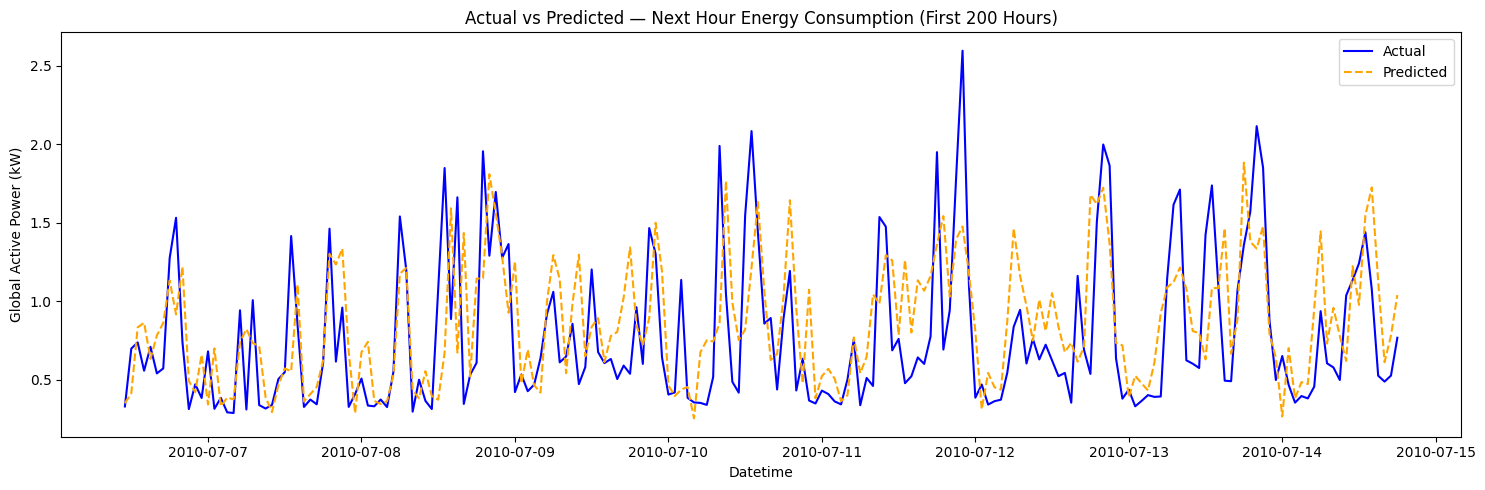

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:200], y_test.values[:200],
         label='Actual', color='blue', linewidth=1.5)
plt.plot(y_test.index[:200], y_pred_test[:200],
         label='Predicted', color='orange', linewidth=1.5, linestyle='--')
plt.title('Actual vs Predicted — Next Hour Energy Consumption (First 200 Hours)')
plt.xlabel('Datetime')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 14: Feature Importance
Let's see which features the model relied on most to make predictions.

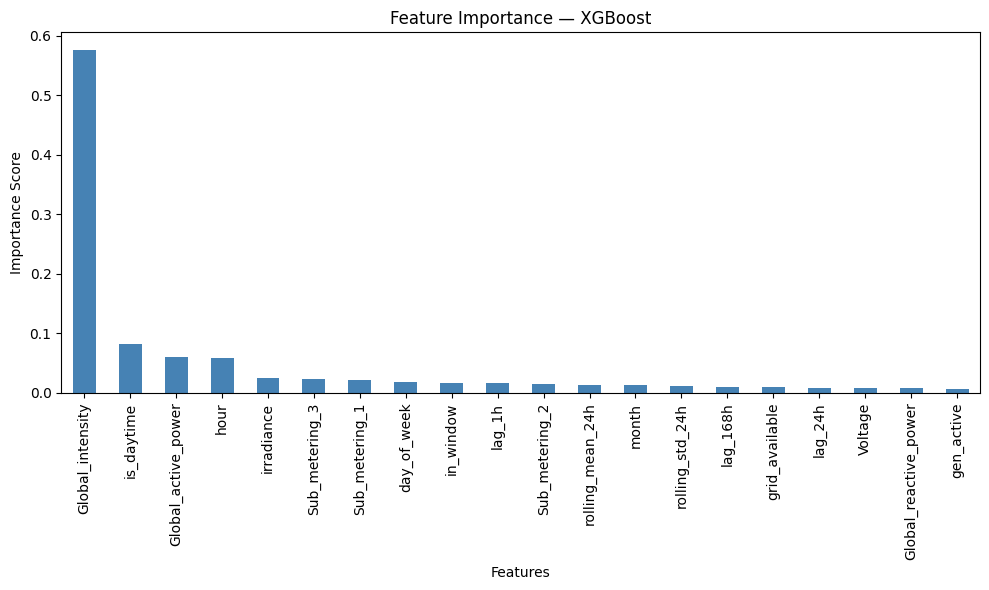

Global_intensity         0.576542
is_daytime               0.082082
Global_active_power      0.060758
hour                     0.057880
irradiance               0.024529
Sub_metering_3           0.022627
Sub_metering_1           0.020967
day_of_week              0.018815
in_window                0.016626
lag_1h                   0.015736
Sub_metering_2           0.014188
rolling_mean_24h         0.013263
month                    0.013141
rolling_std_24h          0.011477
lag_168h                 0.009698
grid_available           0.009658
lag_24h                  0.008880
Voltage                  0.008485
Global_reactive_power    0.008116
gen_active               0.006531
dtype: float32


In [31]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — XGBoost')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

print(importance)

## Step 15: Save the Model
Let's save the trained model so it can be reused without retraining.

In [32]:
import joblib

joblib.dump(model, 'energy_forecast_model.pkl')

print("Model saved successfully as 'energy_forecast_model.pkl'")
print(f"File size: {__import__('os').path.getsize('energy_forecast_model.pkl') / 1024:.1f} KB")

Model saved successfully as 'energy_forecast_model.pkl'
File size: 2236.2 KB


# PART E: GRU Training & Evaluation


## Step 1: Define GRU feature set and build windowed sequences:

In [33]:
gru_exclude_cols = ['lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'target']
gru_feature_cols = [col for col in df_hourly.columns if col not in gru_exclude_cols]

print(f"GRU feature columns ({len(gru_feature_cols)}):")
print(gru_feature_cols)

WINDOW = 24  # hours of history per training example

def create_sequences(data, target, window):
    X_seq, y_seq = [], []
    for i in range(len(data) - window):
        X_seq.append(data[i:i+window])
        y_seq.append(target[i+window])
    return np.array(X_seq), np.array(y_seq)

feature_array = df_hourly[gru_feature_cols].values
target_array  = df_hourly['target'].values

X_gru, y_gru = create_sequences(feature_array, target_array, WINDOW)

print(f"\nX_gru shape: {X_gru.shape}")   # (samples, window, features)
print(f"y_gru shape: {y_gru.shape}")

GRU feature columns (15):
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'month', 'is_daytime', 'irradiance', 'grid_available', 'gen_active', 'in_window']

X_gru shape: (34396, 24, 15)
y_gru shape: (34396,)


## Step 2: Scale features and chronological train/val/test split.

In [34]:
from sklearn.preprocessing import StandardScaler

n = len(X_gru)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

X_train_raw, y_train_gru = X_gru[:train_end], y_gru[:train_end]
X_val_raw,   y_val_gru   = X_gru[train_end:val_end], y_gru[train_end:val_end]
X_test_raw,  y_test_gru  = X_gru[val_end:], y_gru[val_end:]

# Fit scaler on TRAINING data only, reshape to 2D for fitting, then back to 3D
n_features = X_train_raw.shape[2]

scaler = StandardScaler()
scaler.fit(X_train_raw.reshape(-1, n_features))

def scale_sequences(X, scaler, n_features):
    shape = X.shape
    X_flat = X.reshape(-1, n_features)
    X_scaled = scaler.transform(X_flat)
    return X_scaled.reshape(shape)

X_train_gru = scale_sequences(X_train_raw, scaler, n_features)
X_val_gru   = scale_sequences(X_val_raw, scaler, n_features)
X_test_gru  = scale_sequences(X_test_raw, scaler, n_features)

print(f"Train: {X_train_gru.shape}, {y_train_gru.shape}")
print(f"Val  : {X_val_gru.shape}, {y_val_gru.shape}")
print(f"Test : {X_test_gru.shape}, {y_test_gru.shape}")

Train: (27516, 24, 15), (27516,)
Val  : (3440, 24, 15), (3440,)
Test : (3440, 24, 15), (3440,)


## Step 3: Build and train the GRU model

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

model_gru = Sequential([
    GRU(32, input_shape=(WINDOW, n_features), return_sequences=False),
    Dense(16, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_gru.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_gru.fit(
    X_train_gru, y_train_gru,
    validation_data=(X_val_gru, y_val_gru),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.5267 - mae: 0.5263 - val_loss: 0.3568 - val_mae: 0.4473
Epoch 2/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.4354 - mae: 0.4717 - val_loss: 0.3406 - val_mae: 0.4313
Epoch 3/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.4130 - mae: 0.4533 - val_loss: 0.3331 - val_mae: 0.4238
Epoch 4/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.4003 - mae: 0.4438 - val_loss: 0.3298 - val_mae: 0.4197
Epoch 5/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.3921 - mae: 0.4379 - val_loss: 0.3278 - val_mae: 0.4172
Epoch 6/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.3857 - mae: 0.4336 - val_loss: 0.3259 - val_mae: 0.4156
Epoch 7/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.3806 - mae: 0.4304 - val_loss: 0.3253 - val_mae: 0.4152
Epoch 8/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.3761 - mae: 0.4277 - val_loss: 0.3252 - val_mae: 0.4154
Epoch 9/100
430/430 ━━━━━━━━━━━━━━━━━━━━

## Step 4: Evaluate on val and test sets, in the same units as XGBoost (unscaled kW), so the comparison is apples-to-apples

In [36]:
y_pred_val_gru  = model_gru.predict(X_val_gru).flatten()
y_pred_test_gru = model_gru.predict(X_test_gru).flatten()

# Validation metrics
MAE_val  = mean_absolute_error(y_val_gru, y_pred_val_gru)
RMSE_val = np.sqrt(mean_squared_error(y_val_gru, y_pred_val_gru))
MAPE_val = np.mean(np.abs((y_val_gru - y_pred_val_gru) / y_val_gru)) * 100

print("GRU Validation Results:")
print(f"MAE  : {MAE_val:.4f}")
print(f"RMSE : {RMSE_val:.4f}")
print(f"MAPE : {MAPE_val:.4f}%")

# Test metrics
MAE_test  = mean_absolute_error(y_test_gru, y_pred_test_gru)
RMSE_test = np.sqrt(mean_squared_error(y_test_gru, y_pred_test_gru))
MAPE_test = np.mean(np.abs((y_test_gru - y_pred_test_gru) / y_test_gru)) * 100

print("\nGRU Test Results:")
print(f"MAE  : {MAE_test:.4f}")
print(f"RMSE : {RMSE_test:.4f}")
print(f"MAPE : {MAPE_test:.4f}%")

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
GRU Validation Results:
MAE  : 0.4152
RMSE : 0.5702
MAPE : 51.3239%

GRU Test Results:
MAE  : 0.3837
RMSE : 0.5348
MAPE : 58.4422%


## Step 5: Save the GRU model

In [37]:
model_gru.save('energy_forecast_model_gru.keras')

import os
size_kb = os.path.getsize('energy_forecast_model_gru.keras') / 1024
print(f"Model saved successfully as 'energy_forecast_model_gru.keras'")
print(f"File size: {size_kb:.1f} KB")

Model saved successfully as 'energy_forecast_model_gru.keras'
File size: 89.9 KB


In [38]:
import joblib
joblib.dump(scaler, 'gru_feature_scaler.pkl')
print("Scaler saved as 'gru_feature_scaler.pkl'")

Scaler saved as 'gru_feature_scaler.pkl'


# Part F: Compression & Edge Benchmarking

Rebuild GRU with unroll=True for TFLite compatibility

In [39]:
from tensorflow.keras import Input

model_gru_tflite_ready = Sequential([
    Input(shape=(WINDOW, n_features)),
    GRU(32, return_sequences=False, unroll=True),  # unroll=True fixes TFLite conversion
    Dense(16, activation='relu'),
    Dense(1)
])

# Copy the already-trained weights — architecture is identical, just unroll flag differs
model_gru_tflite_ready.set_weights(model_gru.get_weights())

# Sanity check: predictions should match the original trained model closely
sample_pred_original = model_gru.predict(X_test_gru[:5]).flatten()
sample_pred_rebuilt  = model_gru_tflite_ready.predict(X_test_gru[:5]).flatten()

print("Original model predictions:", sample_pred_original)
print("Rebuilt model predictions :", sample_pred_rebuilt)
print("Max difference:", np.max(np.abs(sample_pred_original - sample_pred_rebuilt)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 945ms/step
Original model predictions: [0.46192417 0.7580102  0.8785468  0.7737285  1.0263348 ]
Rebuilt model predictions : [0.46192417 0.7580102  0.8785468  0.7737285  1.0263348 ]
Max difference: 0.0


## Step 1: TFLite conversion, using the unroll-fixed model

In [40]:
# --- 1. Baseline TFLite conversion (no quantization) ---
converter = tf.lite.TFLiteConverter.from_keras_model(model_gru_tflite_ready)
tflite_model_fp32 = converter.convert()

with open('gru_fp32.tflite', 'wb') as f:
    f.write(tflite_model_fp32)

size_fp32 = os.path.getsize('gru_fp32.tflite') / 1024
print(f"Float32 TFLite size: {size_fp32:.2f} KB")

# --- 2. Float16 quantization ---
converter = tf.lite.TFLiteConverter.from_keras_model(model_gru_tflite_ready)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model_fp16 = converter.convert()

with open('gru_fp16.tflite', 'wb') as f:
    f.write(tflite_model_fp16)

size_fp16 = os.path.getsize('gru_fp16.tflite') / 1024
print(f"Float16 quantized TFLite size: {size_fp16:.2f} KB")

# --- 3. Dynamic-range int8 quantization ---
converter = tf.lite.TFLiteConverter.from_keras_model(model_gru_tflite_ready)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_int8_dynamic = converter.convert()

with open('gru_int8_dynamic.tflite', 'wb') as f:
    f.write(tflite_model_int8_dynamic)

size_int8_dynamic = os.path.getsize('gru_int8_dynamic.tflite') / 1024
print(f"Dynamic-range quantized TFLite size: {size_int8_dynamic:.2f} KB")

print(f"\nOriginal Keras (.keras) size: 89.9 KB")
print(f"Reduction (fp32 TFLite): {(1 - size_fp32/89.9)*100:.1f}%")
print(f"Reduction (fp16): {(1 - size_fp16/89.9)*100:.1f}%")
print(f"Reduction (int8 dynamic): {(1 - size_int8_dynamic/89.9)*100:.1f}%")

Saved artifact at '/tmp/tmpg6pjni68'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 15), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134648937221584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134648937234064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134648937225040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134648937230224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134648937232144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134648937231184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134648937224080: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32 TFLite size: 101.79 KB
Saved artifact at '/tmp/tmpunlsin6a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 15), dtype=tf.float32, name='keras_tensor_4')

## Step 2: XGBoost compression: reduce n_estimators/max_depth, measure size and accuracy tradeoff.

In [41]:
configs = [
    {"n_estimators": 500, "max_depth": 6, "label": "original"},
    {"n_estimators": 200, "max_depth": 6, "label": "fewer_trees_200"},
    {"n_estimators": 100, "max_depth": 6, "label": "fewer_trees_100"},
    {"n_estimators": 100, "max_depth": 4, "label": "shallow_100_d4"},
    {"n_estimators": 50,  "max_depth": 4, "label": "compact_50_d4"},
]

results = []

for cfg in configs:
    m = XGBRegressor(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    fname = f"xgb_{cfg['label']}.pkl"
    joblib.dump(m, fname)
    size_kb = os.path.getsize(fname) / 1024

    y_pred = m.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    results.append({
        "config": cfg["label"],
        "n_estimators": cfg["n_estimators"],
        "max_depth": cfg["max_depth"],
        "size_kb": size_kb,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

    print(f"{cfg['label']:20s} | size={size_kb:8.1f} KB | MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.2f}%")

results_df = pd.DataFrame(results)
print("\n", results_df)

original             | size=  2236.2 KB | MAE=0.3035 | RMSE=0.4389 | MAPE=43.38%
fewer_trees_200      | size=   907.3 KB | MAE=0.2992 | RMSE=0.4339 | MAPE=42.36%
fewer_trees_100      | size=   479.9 KB | MAE=0.3018 | RMSE=0.4337 | MAPE=43.46%
shallow_100_d4       | size=   179.4 KB | MAE=0.3121 | RMSE=0.4408 | MAPE=46.70%
compact_50_d4        | size=    95.5 KB | MAE=0.3384 | RMSE=0.4589 | MAPE=55.18%

             config  n_estimators  max_depth      size_kb       MAE      RMSE  \
0         original           500          6  2236.157227  0.303476  0.438868   
1  fewer_trees_200           200          6   907.273438  0.299205  0.433937   
2  fewer_trees_100           100          6   479.877930  0.301822  0.433656   
3   shallow_100_d4           100          4   179.365234  0.312113  0.440790   
4    compact_50_d4            50          4    95.529297  0.338382  0.458884   

        MAPE  
0  43.383897  
1  42.362054  
2  43.464721  
3  46.698675  
4  55.178551  


## Step 3: Relative CPU-based inference latency (Colab-measured, with the caveat noted in our methodology).

In [42]:
import time

def time_single_inference(predict_fn, X_sample, n_runs=200):
    # Warm-up run (excluded from timing) — avoids first-call overhead skewing results
    _ = predict_fn(X_sample)

    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = predict_fn(X_sample)
        end = time.perf_counter()
        times.append((end - start) * 1000)  # convert to ms

    return np.mean(times), np.std(times)

# --- XGBoost variants ---
xgb_variants = {
    "XGBoost (original, 500/6)": joblib.load("xgb_original.pkl"),
    "XGBoost (100/6, best accuracy)": joblib.load("xgb_fewer_trees_100.pkl"),
    "XGBoost (50/4, compact)": joblib.load("xgb_compact_50_d4.pkl"),
}

X_single_xgb = X_test.iloc[[0]]  # single row, same shape a real deployment would feed in

print("=== XGBoost Latency (single-sample, avg of 200 runs) ===")
for name, m in xgb_variants.items():
    mean_ms, std_ms = time_single_inference(lambda X: m.predict(X), X_single_xgb)
    print(f"{name:35s} | {mean_ms:.3f} ms  (± {std_ms:.3f})")

# --- GRU ---
X_single_gru = X_test_gru[0:1]  # single windowed sequence, shape (1, 24, 15)

print("\n=== GRU Latency (single-sample, avg of 200 runs) ===")
mean_ms_gru, std_ms_gru = time_single_inference(
    lambda X: model_gru_tflite_ready.predict(X, verbose=0), X_single_gru
)
print(f"{'GRU (native Keras)':35s} | {mean_ms_gru:.3f} ms  (± {std_ms_gru:.3f})")

=== XGBoost Latency (single-sample, avg of 200 runs) ===
XGBoost (original, 500/6)           | 4.886 ms  (± 4.617)
XGBoost (100/6, best accuracy)      | 9.368 ms  (± 6.001)
XGBoost (50/4, compact)             | 7.047 ms  (± 5.580)

=== GRU Latency (single-sample, avg of 200 runs) ===
GRU (native Keras)                  | 81.495 ms  (± 21.461)


# Part G: Outage-Aware Imputation Ablation

## Step 1: Prepare the ground-truth series and outage indicator for masking.

In [43]:
#Outage-Aware Imputation Ablation — Step 1: Prepare Ground Truth + Outage Indicator

# Ground truth: the complete Global_active_power series (post-calibration, no missing values)
ground_truth = df_hourly['Global_active_power'].copy()

# Reconstruct no_power locally (grid off AND irradiance-based solar proxy insufficient)
# — same logic used during generator calibration, rebuilt here since it was dropped as scaffolding
max_irr = df_hourly['irradiance'].quantile(0.99)
solar_proxy = (df_hourly['irradiance'] / max_irr).clip(0, 1)

no_power_mask = (df_hourly['grid_available'] == 0) & (solar_proxy < 0.2)

print(f"Total hours: {len(df_hourly)}")
print(f"Hours with no_power=True: {no_power_mask.sum()} ({no_power_mask.mean()*100:.2f}%)")
print(f"\nGround truth sample:\n{ground_truth.head()}")

Total hours: 34420
Hours with no_power=True: 14470 (42.04%)

Ground truth sample:
dt
2006-12-23 17:00:00    5.452533
2006-12-23 18:00:00    3.879400
2006-12-23 19:00:00    4.117833
2006-12-23 20:00:00    4.181400
2006-12-23 21:00:00    3.288433
Freq: h, Name: Global_active_power, dtype: float64


## Step 2: Inject two types of synthetic missingness at matched overall rates — MCAR (random) vs. MNAR (outage-correlated

In [44]:
#Part G, Step 2: Inject Synthetic Missingness (MCAR vs. MNAR)

np.random.seed(42)

MISSING_RATE = 0.10  # 10% of hours masked, matching roughly the ~1.25% UCI rate scaled up
                      # for a clearer experimental signal — flagged explicitly below

n_total = len(ground_truth)
n_missing = int(n_total * MISSING_RATE)

# --- MCAR: missing completely at random, uniform over all hours ---
mcar_missing_idx = np.random.choice(ground_truth.index, size=n_missing, replace=False)
series_mcar = ground_truth.copy()
series_mcar.loc[mcar_missing_idx] = np.nan

# --- MNAR: missing concentrated during no_power hours ---
# Sample preferentially from no_power=True hours; fall back to random hours if not enough
no_power_hours = df_hourly.index[no_power_mask]
n_from_outage = min(n_missing, len(no_power_hours))

mnar_missing_idx = np.random.choice(no_power_hours, size=n_from_outage, replace=False)

# If MISSING_RATE requires more than available no_power hours, top up randomly from the rest
if n_from_outage < n_missing:
    remaining_pool = ground_truth.index.difference(mnar_missing_idx)
    extra_needed = n_missing - n_from_outage
    extra_idx = np.random.choice(remaining_pool, size=extra_needed, replace=False)
    mnar_missing_idx = mnar_missing_idx.union(extra_idx)

series_mnar = ground_truth.copy()
series_mnar.loc[mnar_missing_idx] = np.nan

print(f"Target missing count: {n_missing} ({MISSING_RATE*100:.0f}%)")
print(f"MCAR actual missing: {series_mcar.isnull().sum()}")
print(f"MNAR actual missing: {series_mnar.isnull().sum()}")
print(f"MNAR missing hours that fall within no_power windows: {no_power_mask.loc[mnar_missing_idx].sum()} / {len(mnar_missing_idx)}")

Target missing count: 3442 (10%)
MCAR actual missing: 3442
MNAR actual missing: 3442
MNAR missing hours that fall within no_power windows: 3442 / 3442


## Step 3: Apply two imputation strategies to each masked series, then measure imputation error against the known ground truth.

In [45]:
#Part G, Step 3: Apply Imputation Strategies and Measure Error

def naive_ffill_impute(series):
    return series.ffill()

def type_aware_impute(series, no_power_mask, ground_truth_full):
    """
    For gaps that fall within known no_power hours: impute using the
    average consumption for that (hour, is_weekend) profile, rather than
    blindly carrying forward the last observed value — reflecting that an
    outage-driven gap is informative, not a continuation of pre-outage behavior.
    For gaps outside no_power hours (sensor-fault-like): use standard forward-fill.
    """
    imputed = series.copy()
    missing_idx = series[series.isnull()].index

    # Build an hour-of-day / weekend consumption profile from OBSERVED (non-missing) data only
    observed = series.dropna()
    profile_df = pd.DataFrame({
        'value': observed,
        'hour': observed.index.hour,
        'is_weekend': observed.index.dayofweek.isin([5, 6]).astype(int)
    })
    hour_profile = profile_df.groupby(['hour', 'is_weekend'])['value'].mean()

    for idx in missing_idx:
        if no_power_mask.get(idx, False):
            hour = idx.hour
            is_weekend = int(idx.dayofweek in [5, 6])
            imputed.loc[idx] = hour_profile.get((hour, is_weekend), series.ffill().loc[idx])
        else:
            # fallback: forward-fill for non-outage (sensor-fault-like) gaps
            imputed.loc[idx] = series.ffill().loc[idx]

    return imputed

# --- Apply both strategies to both missingness types ---
mcar_naive     = naive_ffill_impute(series_mcar)
mcar_typeaware = type_aware_impute(series_mcar, no_power_mask, ground_truth)

mnar_naive     = naive_ffill_impute(series_mnar)
mnar_typeaware = type_aware_impute(series_mnar, no_power_mask, ground_truth)

# --- Measure imputation error against ground truth, only at the originally-missing positions ---
def imputation_rmse(imputed, ground_truth, missing_idx):
    return np.sqrt(mean_squared_error(ground_truth.loc[missing_idx], imputed.loc[missing_idx]))

results_imputation = {
    "MCAR + naive ffill":      imputation_rmse(mcar_naive, ground_truth, mcar_missing_idx),
    "MCAR + type-aware":       imputation_rmse(mcar_typeaware, ground_truth, mcar_missing_idx),
    "MNAR + naive ffill":      imputation_rmse(mnar_naive, ground_truth, mnar_missing_idx),
    "MNAR + type-aware":       imputation_rmse(mnar_typeaware, ground_truth, mnar_missing_idx),
}

for k, v in results_imputation.items():
    print(f"{k:25s} RMSE: {v:.4f}")

MCAR + naive ffill        RMSE: 0.6838
MCAR + type-aware         RMSE: 0.6975
MNAR + naive ffill        RMSE: 0.6915
MNAR + type-aware         RMSE: 0.6796
